In [ ]:
!pip install --upgrade scikeras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 86.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


Train images shape: (60000, 28, 28)
Train labels shape : (60000,)
Test images shape  : (10000, 28, 28)
Test labels shape  : (10000,)


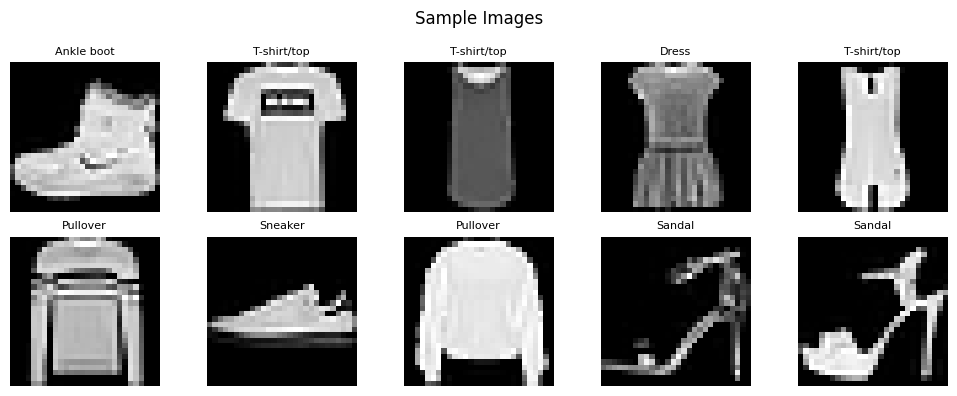

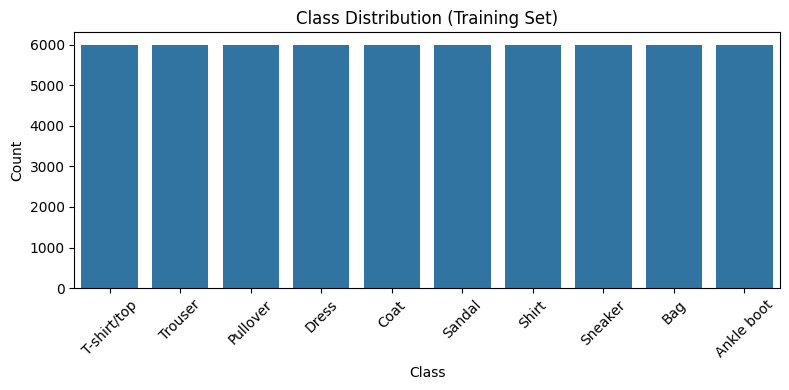


Before preprocessing:
x_train: (60000, 28, 28) dtype: uint8

After preprocessing:
x_train_flat: (60000, 784) dtype: float32
y_train_oh  : (60000, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from scikeras.wrappers import KerasClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# ---------------------------------------------------------------------
# Task 1: Dataset Exploration
# ---------------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train images shape:", x_train.shape)
print("Train labels shape :", y_train.shape)
print("Test images shape  :", x_test.shape)
print("Test labels shape  :", y_test.shape)

# Sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample Images")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

# Class distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train)
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45)
plt.title("Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

# ---------------------------------------------------------------------
# Task 2: Data Preprocessing
# ---------------------------------------------------------------------
print("\nBefore preprocessing:")
print("x_train:", x_train.shape, "dtype:", x_train.dtype)

# Flatten
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Normalize to [0, 1]
x_train_flat = x_train_flat.astype("float32") / 255.0
x_test_flat = x_test_flat.astype("float32") / 255.0

# One-hot encode labels
y_train_oh = keras.utils.to_categorical(y_train, num_classes=10)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=10)

print("\nAfter preprocessing:")
print("x_train_flat:", x_train_flat.shape, "dtype:", x_train_flat.dtype)
print("y_train_oh  :", y_train_oh.shape)

# ---------------------------------------------------------------------
# Task 3: Model Construction (Baseline)
# ---------------------------------------------------------------------
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()



Epoch 1/20
1688/1688 - 8s - 5ms/step - accuracy: 0.8205 - loss: 0.5018 - val_accuracy: 0.8473 - val_loss: 0.4039
Epoch 2/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8628 - loss: 0.3750 - val_accuracy: 0.8583 - val_loss: 0.3678
Epoch 3/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8754 - loss: 0.3370 - val_accuracy: 0.8677 - val_loss: 0.3529
Epoch 4/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8854 - loss: 0.3113 - val_accuracy: 0.8693 - val_loss: 0.3498
Epoch 5/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8923 - loss: 0.2913 - val_accuracy: 0.8713 - val_loss: 0.3500
Epoch 6/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8977 - loss: 0.2752 - val_accuracy: 0.8717 - val_loss: 0.3510
Epoch 7/20
1688/1688 - 8s - 5ms/step - accuracy: 0.9032 - loss: 0.2592 - val_accuracy: 0.8702 - val_loss: 0.3750
Epoch 8/20
1688/1688 - 6s - 3ms/step - accuracy: 0.9066 - loss: 0.2492 - val_accuracy: 0.8708 - val_loss: 0.3785
Epoch 9/20
1688/1688 - 5s - 3ms/step - accuracy: 0.9087 - loss: 0.2413 - val_accuracy: 0.8795 - 

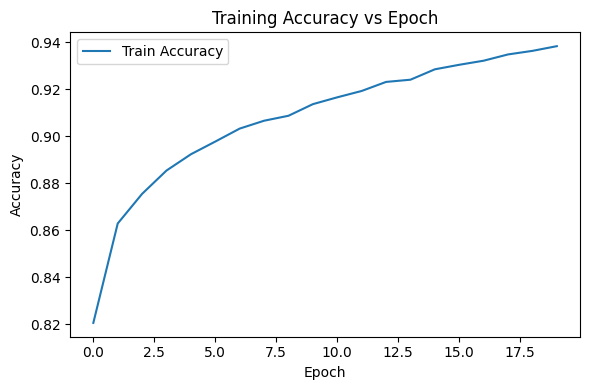

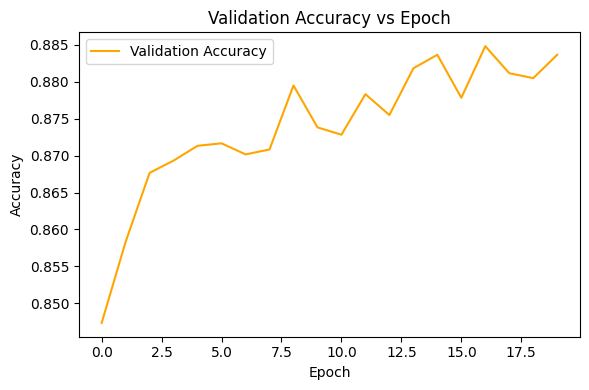

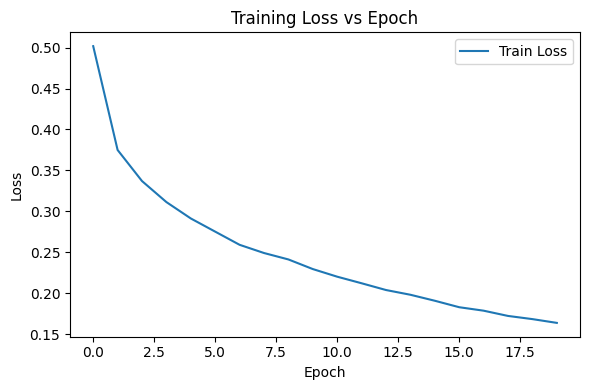

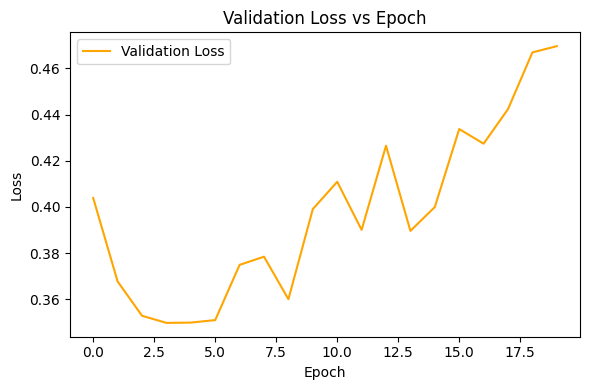

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Baseline Metrics: {'accuracy': 0.8792, 'precision': 0.8820142843514371, 'recall': 0.8792, 'f1': 0.8748012200809304}


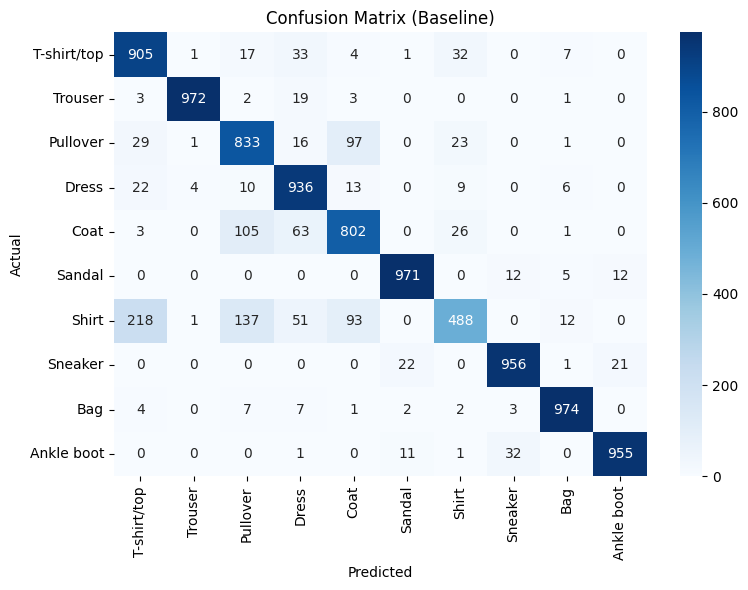


Classification Report (Baseline):
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.91      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.75      0.83      0.79      1000
       Dress       0.83      0.94      0.88      1000
        Coat       0.79      0.80      0.80      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.84      0.49      0.62      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, optimizer

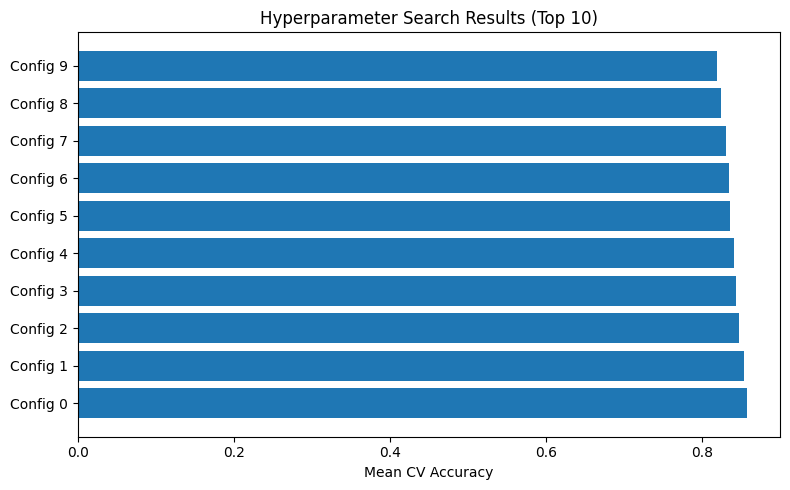

Epoch 1/30
1688/1688 - 10s - 6ms/step - accuracy: 0.7942 - loss: 0.5697 - val_accuracy: 0.8290 - val_loss: 0.4762
Epoch 2/30
1688/1688 - 5s - 3ms/step - accuracy: 0.8402 - loss: 0.4468 - val_accuracy: 0.8592 - val_loss: 0.4018
Epoch 3/30
1688/1688 - 4s - 3ms/step - accuracy: 0.8511 - loss: 0.4135 - val_accuracy: 0.8635 - val_loss: 0.3841
Epoch 4/30
1688/1688 - 5s - 3ms/step - accuracy: 0.8611 - loss: 0.3907 - val_accuracy: 0.8728 - val_loss: 0.3636
Epoch 5/30
1688/1688 - 4s - 3ms/step - accuracy: 0.8658 - loss: 0.3752 - val_accuracy: 0.8752 - val_loss: 0.3526
Epoch 6/30
1688/1688 - 5s - 3ms/step - accuracy: 0.8701 - loss: 0.3626 - val_accuracy: 0.8760 - val_loss: 0.3517
Epoch 7/30
1688/1688 - 5s - 3ms/step - accuracy: 0.8730 - loss: 0.3542 - val_accuracy: 0.8757 - val_loss: 0.3489
Epoch 8/30
1688/1688 - 5s - 3ms/step - accuracy: 0.8767 - loss: 0.3435 - val_accuracy: 0.8742 - val_loss: 0.3478
Epoch 9/30
1688/1688 - 5s - 3ms/step - accuracy: 0.8799 - loss: 0.3389 - val_accuracy: 0.8802 -

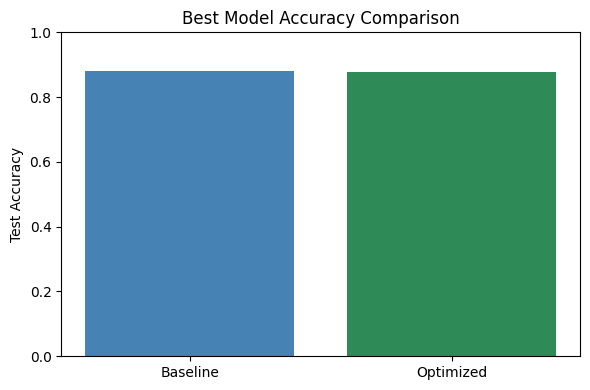


Metric         Baseline       Optimized      
Accuracy       0.8792         0.8787         
Precision      0.8820         0.8792         
Recall         0.8792         0.8787         
F1             0.8748         0.8773         
Time (s)       114.95         148.46         


In [ ]:
# ---------------------------------------------------------------------
# Task 4: Model Training (Baseline)
# ---------------------------------------------------------------------
import time
start = time.time()
history = baseline_model.fit(
    x_train_flat, y_train_oh,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=2,
)
baseline_train_time = time.time() - start

# Training curves
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout(); plt.savefig("train_accuracy.png"); plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout(); plt.savefig("val_accuracy.png"); plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("train_loss.png"); plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["val_loss"], label="Validation Loss", color="orange")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("val_loss.png"); plt.show()

# ---------------------------------------------------------------------
# Task 5: Model Evaluation (Baseline)
# ---------------------------------------------------------------------
y_pred_probs = baseline_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average="macro"),
    "recall": recall_score(y_test, y_pred, average="macro"),
    "f1": f1_score(y_test, y_pred, average="macro"),
}
print("\nBaseline Metrics:", baseline_metrics)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix (Baseline)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.savefig("confusion_matrix.png"); plt.show()

print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ---------------------------------------------------------------------
# Hyperparameter Optimization: RandomizedSearchCV + SciKeras
# ---------------------------------------------------------------------
def build_tunable_model(meta, hidden_layers=1, hidden_neurons=128,
                         learning_rate=0.001, activation="relu",
                         dropout_rate=0.0):
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]

    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features_in,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation="softmax"))

    optimizer_map = {
        "adam": keras.optimizers.Adam(learning_rate=learning_rate),
        "sgd": keras.optimizers.SGD(learning_rate=learning_rate),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=learning_rate),
    }
    model.compile(
        optimizer=optimizer_map["adam"],  # overridden below via param grid trick
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# NOTE: SciKeras handles optimizer as a top-level param too; simpler pattern below.
def build_tunable_model_v2(meta, hidden_layers=1, hidden_neurons=128,
                            activation="relu", dropout_rate=0.0):
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features_in,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation="softmax"))
    return model

clf = KerasClassifier(
    model=build_tunable_model_v2,
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    verbose=0,
)

# Use a stratified subsample for faster search (full grid on 60k is expensive)
from sklearn.model_selection import train_test_split
x_sub, _, y_sub, _ = train_test_split(
    x_train_flat, y_train, train_size=10000,
    stratify=y_train, random_state=RANDOM_STATE
)

param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "optimizer": ["sgd", "adam", "rmsprop"],
    "optimizer__learning_rate": [0.1, 0.01, 0.001],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
}

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=1,
)

search.fit(x_sub, y_sub)

print("\nBest Hyperparameters:", search.best_params_)
print("Best CV Accuracy:", search.best_score_)

# Hyperparameter search results plot (top 10 by mean test score)
import pandas as pd
results_df = pd.DataFrame(search.cv_results_)
top10 = results_df.sort_values("mean_test_score", ascending=False).head(10)
plt.figure(figsize=(8, 5))
plt.barh(range(len(top10)), top10["mean_test_score"])
plt.yticks(range(len(top10)), [f"Config {i}" for i in range(len(top10))])
plt.xlabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results (Top 10)")
plt.tight_layout(); plt.savefig("hp_search_results.png"); plt.show()

# ---------------------------------------------------------------------
# Retrain optimized model on full training set
# ---------------------------------------------------------------------
best_params = search.best_params_

optimized_model = keras.Sequential()
optimized_model.add(layers.Input(shape=(784,)))
for _ in range(best_params["model__hidden_layers"]):
    optimized_model.add(layers.Dense(
        best_params["model__hidden_neurons"],
        activation=best_params["model__activation"]
    ))
    if best_params["model__dropout_rate"] > 0:
        optimized_model.add(layers.Dropout(best_params["model__dropout_rate"]))
optimized_model.add(layers.Dense(10, activation="softmax"))

optimizer_map = {
    "adam": keras.optimizers.Adam(learning_rate=best_params["optimizer__learning_rate"]),
    "sgd": keras.optimizers.SGD(learning_rate=best_params["optimizer__learning_rate"]),
    "rmsprop": keras.optimizers.RMSprop(learning_rate=best_params["optimizer__learning_rate"]),
}
optimized_model.compile(
    optimizer=optimizer_map[best_params["optimizer"]],
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

start = time.time()
optimized_model.fit(
    x_train_flat, y_train_oh,
    validation_split=0.1,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=2,
)
optimized_train_time = time.time() - start

# ---------------------------------------------------------------------
# Evaluate optimized model on test set
# ---------------------------------------------------------------------
y_pred_probs_opt = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)

optimized_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_opt),
    "precision": precision_score(y_test, y_pred_opt, average="macro"),
    "recall": recall_score(y_test, y_pred_opt, average="macro"),
    "f1": f1_score(y_test, y_pred_opt, average="macro"),
}
print("\nOptimized Metrics:", optimized_metrics)

# ---------------------------------------------------------------------
# Best Model Accuracy Comparison plot
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.bar(
    ["Baseline", "Optimized"],
    [baseline_metrics["accuracy"], optimized_metrics["accuracy"]],
    color=["steelblue", "seagreen"]
)
plt.title("Best Model Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.tight_layout(); plt.savefig("accuracy_comparison.png"); plt.show()

# ---------------------------------------------------------------------
# Final comparison table (print for report)
# ---------------------------------------------------------------------
print("\n{:<15}{:<15}{:<15}".format("Metric", "Baseline", "Optimized"))
for key in ["accuracy", "precision", "recall", "f1"]:
    print("{:<15}{:<15.4f}{:<15.4f}".format(
        key.capitalize(), baseline_metrics[key], optimized_metrics[key]
    ))
print("{:<15}{:<15.2f}{:<15.2f}".format(
    "Time (s)", baseline_train_time, optimized_train_time
))


--- AND Gate ---
Update 1: w=[0. 0.], b=-1


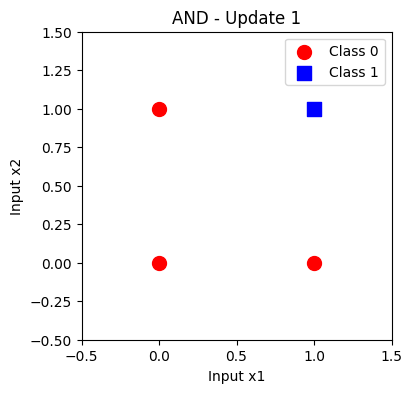

Update 2: w=[1. 1.], b=0


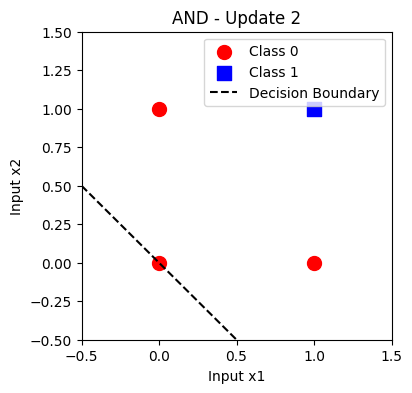

Update 3: w=[1. 1.], b=-1


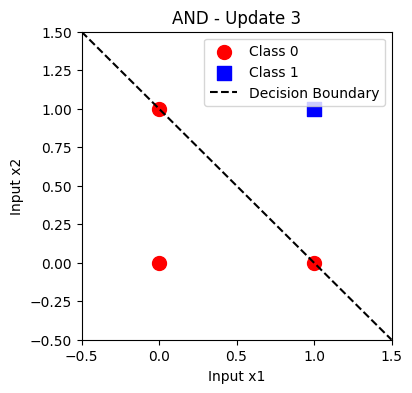

Update 4: w=[1. 0.], b=-2


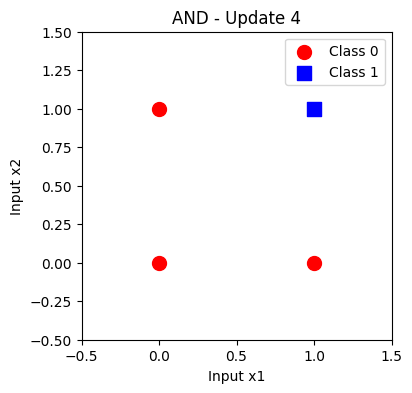

Update 5: w=[2. 1.], b=-1


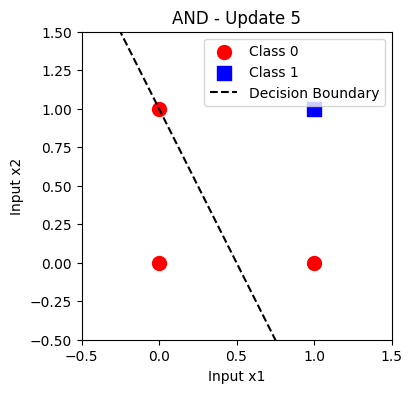

Update 6: w=[2. 0.], b=-2


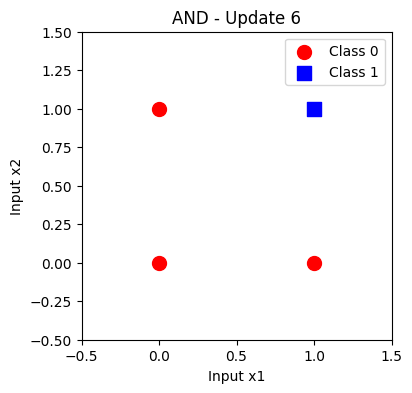

Update 7: w=[1. 0.], b=-3


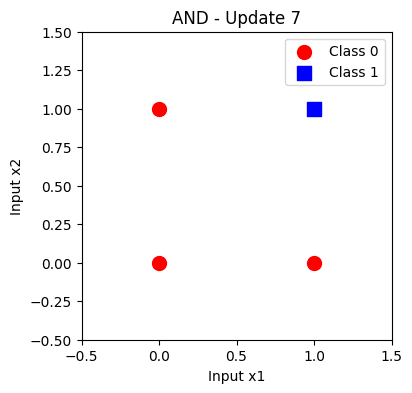

Update 8: w=[2. 1.], b=-2


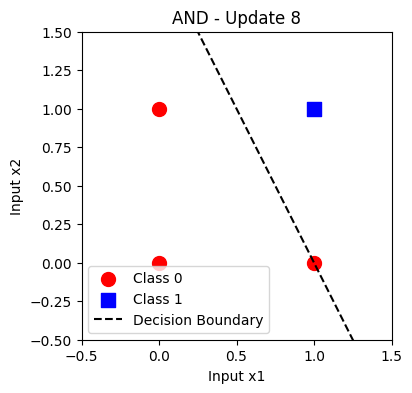

Update 9: w=[1. 1.], b=-3


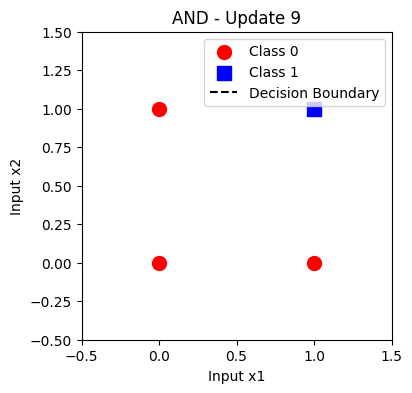

Update 10: w=[2. 2.], b=-2


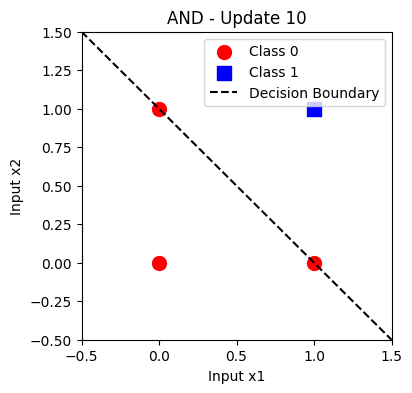

Update 11: w=[2. 1.], b=-3


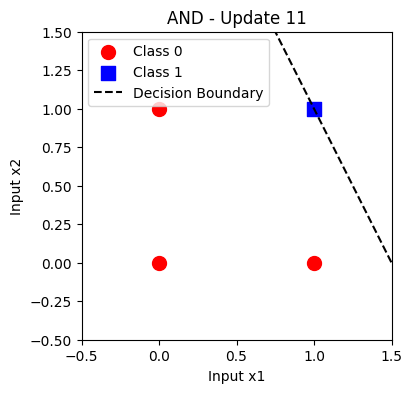

Converged weights: w=[2. 1.], b=-3

--- OR Gate ---
Update 1: w=[0. 0.], b=-1


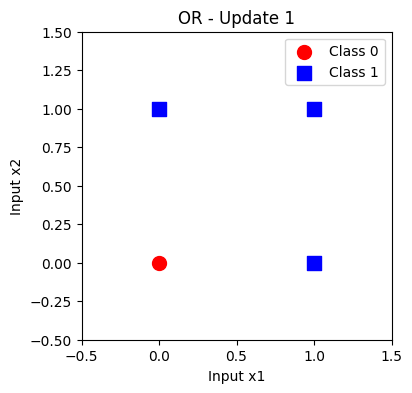

Update 2: w=[0. 1.], b=0


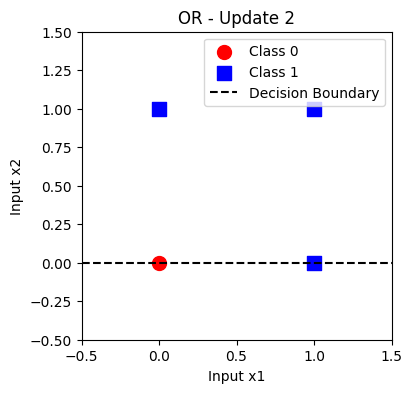

Update 3: w=[0. 1.], b=-1


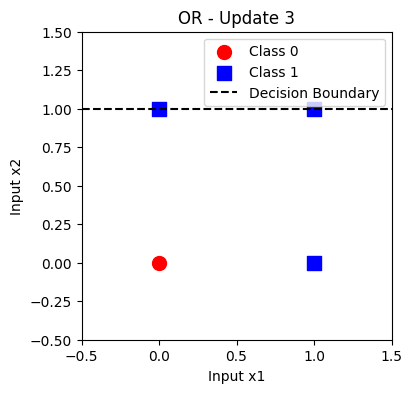

Update 4: w=[1. 1.], b=0


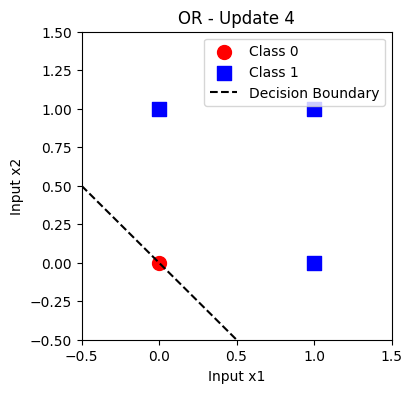

Update 5: w=[1. 1.], b=-1


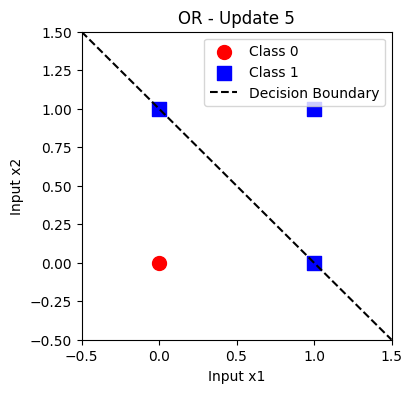

Converged weights: w=[1. 1.], b=-1

--- NOT Gate ---
Update 1: w=[-1.], b=-1


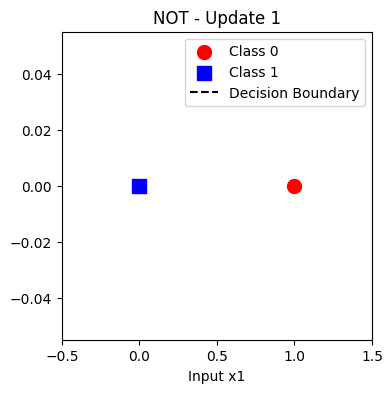

Update 2: w=[-1.], b=0


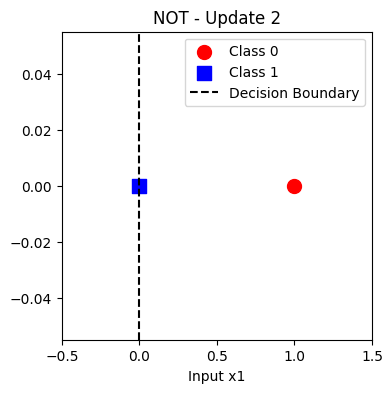

Converged weights: w=[-1.], b=0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_train(X, y, lr=1, epochs=20):
    w = np.zeros(X.shape[1])
    b = 0
    history = []
    for _ in range(epochs):
        errors = 0
        for xi, target in zip(X, y):
            pred = 1 if (np.dot(w, xi) + b) >= 0 else 0
            update = lr * (target - pred)
            if update != 0:
                w = w + update * xi
                b = b + update
                errors += 1
                history.append((w.copy(), b))
        if errors == 0:
            break
    return w, b, history

def plot_boundary(X, y, w, b, title, step):
    plt.figure(figsize=(4,4))
    if X.shape[1] == 2:
        for label, marker, color in [(0,'o','red'),(1,'s','blue')]:
            pts = X[y==label]
            plt.scatter(pts[:,0], pts[:,1], marker=marker, color=color, label=f"Class {label}", s=100)
        x_vals = np.linspace(-0.5,1.5,10)
        if w[1] != 0:
            y_vals = -(w[0]*x_vals + b)/w[1]
            plt.plot(x_vals, y_vals, 'k--', label="Decision Boundary")
        plt.xlabel("Input x1"); plt.ylabel("Input x2")
        plt.xlim(-0.5,1.5); plt.ylim(-0.5,1.5)
    else:
        for label, marker, color in [(0,'o','red'),(1,'s','blue')]:
            pts = X[y==label]
            plt.scatter(pts[:,0], np.zeros_like(pts[:,0]), marker=marker, color=color, label=f"Class {label}", s=100)
        if w[0] != 0:
            thresh = -b/w[0]
            plt.axvline(thresh, color='k', linestyle='--', label="Decision Boundary")
        plt.xlabel("Input x1"); plt.ylabel("")
        plt.xlim(-0.5,1.5)
    plt.title(f"{title} - Update {step}")
    plt.legend()
    plt.show()

gates = {
    "AND": (np.array([[0,0],[0,1],[1,0],[1,1]]), np.array([0,0,0,1])),
    "OR":  (np.array([[0,0],[0,1],[1,0],[1,1]]), np.array([0,1,1,1])),
    "NOT": (np.array([[0],[1]]), np.array([1,0])),
}

for gate_name, (X, y) in gates.items():
    w, b, history = perceptron_train(X, y)
    print(f"\n--- {gate_name} Gate ---")
    for i, (wi, bi) in enumerate(history):
        print(f"Update {i+1}: w={wi}, b={bi}")
        plot_boundary(X, y, wi, bi, gate_name, i+1)
    print(f"Converged weights: w={w}, b={b}")

Ran 198 updates without hitting zero errors — perceptron never converges.
Update 1: w=[0. 0.], b=-1
Update 2: w=[0. 1.], b=0
Update 3: w=[-1.  0.], b=-1
Update 4: w=[-1.  1.], b=0
Update 5: w=[0. 1.], b=1
Update 6: w=[-1.  0.], b=0
Update 7: w=[-1.  0.], b=-1
Update 8: w=[-1.  1.], b=0
Update 9: w=[0. 1.], b=1
Update 10: w=[-1.  0.], b=0
Update 11: w=[-1.  0.], b=-1
Update 12: w=[-1.  1.], b=0
Update 13: w=[0. 1.], b=1
Update 14: w=[-1.  0.], b=0
Update 15: w=[-1.  0.], b=-1
Update 16: w=[-1.  1.], b=0
Update 17: w=[0. 1.], b=1
Update 18: w=[-1.  0.], b=0
Update 19: w=[-1.  0.], b=-1
Update 20: w=[-1.  1.], b=0
Update 21: w=[0. 1.], b=1
Update 22: w=[-1.  0.], b=0
Update 23: w=[-1.  0.], b=-1
Update 24: w=[-1.  1.], b=0
Update 25: w=[0. 1.], b=1
Update 26: w=[-1.  0.], b=0
Update 27: w=[-1.  0.], b=-1
Update 28: w=[-1.  1.], b=0
Update 29: w=[0. 1.], b=1
Update 30: w=[-1.  0.], b=0
Update 31: w=[-1.  0.], b=-1
Update 32: w=[-1.  1.], b=0
Update 33: w=[0. 1.], b=1
Update 34: w=[-1.  0.]

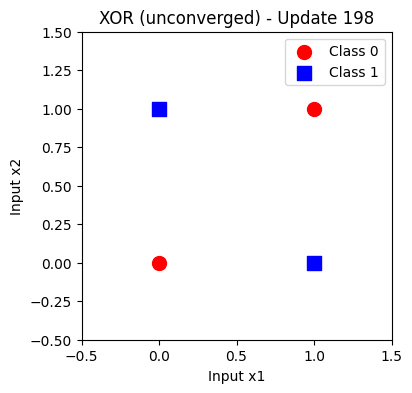

In [ ]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

w, b, history = perceptron_train(X_xor, y_xor, epochs=50)

print(f"Ran {len(history)} updates without hitting zero errors — perceptron never converges.")
for i, (wi, bi) in enumerate(history):
    print(f"Update {i+1}: w={wi}, b={bi}")

plot_boundary(X_xor, y_xor, w, b, "XOR (unconverged)", len(history))

Predictions: [0 1 1 0]
Accuracy: 1.0


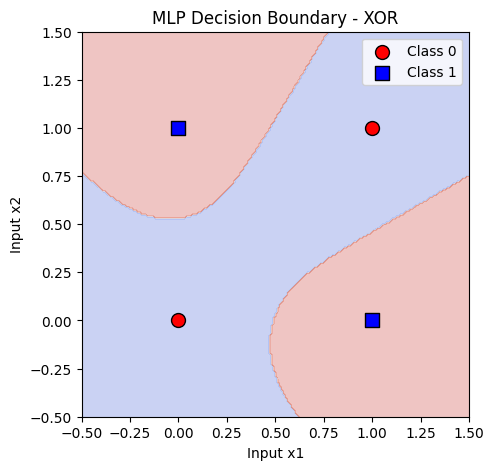

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='tanh', max_iter=5000, random_state=1)
mlp.fit(X_xor, y_xor)

print("Predictions:", mlp.predict(X_xor))
print("Accuracy:", mlp.score(X_xor, y_xor))

xx, yy = np.meshgrid(np.linspace(-0.5,1.5,200), np.linspace(-0.5,1.5,200))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
for label, marker, color in [(0,'o','red'),(1,'s','blue')]:
    pts = X_xor[y_xor==label]
    plt.scatter(pts[:,0], pts[:,1], marker=marker, color=color, label=f"Class {label}", edgecolor='k', s=100)
plt.xlabel("Input x1"); plt.ylabel("Input x2")
plt.title("MLP Decision Boundary - XOR")
plt.legend()
plt.show()